## Rain-on-snow project <br>
#### Definition of ROS zone and events across CONUS, processed by HUC2 region

This notebook exemplifies the process followed to define ROS grid cells, zone and events accross the CONUS. Processing is done by cropping the NWM domain to the padded bounding box of
the GAGES II basin polygons in a single HUC2 region (so no basin is sliced at the domain edge).

All HUC2 regions are later processed using an HPC and codes stored in the `HPC_scripts` directory using
`get_percRos_evs_perHuc2.py`.

In [1]:
import sys
# Path to ROS functions
sys.path.append('../') # Place path to where your ros-workflow directory is

In [2]:
import os
import functions.rain_on_snow_fncns as ros
import functions.rain_on_snow_utils as rosutl
from functions.rain_on_snow_fncns import nwm_proj
import geopandas
import pandas as pd
import xarray
import rioxarray  # registers the .rio accessor used to save the zone raster
import matplotlib.pyplot as plt
import contextily as cx

In [3]:
from dask.distributed import Client
client = Client()
#client = Client(n_workers=6, memory_limit='2GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39007,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44339,Total threads: 4
Dashboard: http://127.0.0.1:42179/status,Memory: 62.80 GiB
Nanny: tcp://127.0.0.1:32915,


#### 1. Configuration

In [4]:
# Path to AWS NWM retrospective data
s3_path = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr'
#timerange = slice('2019-01-01 00:00:00','2020-12-31 18:00:00')
timerange = slice('1979-10-01 00:00:00','2022-09-30 18:00:00')
variables = ["SNEQV", "QRAIN"]

# Set `huc2 = '01'` to test processing only the HUC2 Northeast region
huc2 = '01'
# Define the rule to define ROS zone: a cell must have >=1 ROS day in every water year, so the
# threshold is the number of water years in the record (43 for the full 1979-2022 slice above).
# Pass a smaller int to relax (e.g. 40 of 43), and lower it to match if you uncomment the short
# timerange. Define_ros_zone raises an error when the threshold exceeds the water years actually present.
threshold = 43
# ROS events are defined by batches. Define a year-batch size here (lower it for large western regions if memory is tight).
batch_size_years = 2

# GAGES II basin polygons + CONUS metadata (GAGE_ID -> HUC02 membership)
shp_dir = '/netfiles/ciroh/mmorales/ROS_project/shapefiles/GAGES_II/boundaries_shapefiles_by_aggeco/boundaries-shapefiles-by-aggeco/'
metadata_path = '../input/Metadata_GAGESII_ROS.parquet'

# Output directory + basin-class subfolders. Output is defined here as "sandbox" only for testing purposes with NE region
# Conus scale outputs are saved in ../output
saveDir = './output_sandbox' 
bsn_class = ('ref', 'nonref')
os.makedirs(saveDir, exist_ok=True)

#### 2. Select the HUC2 basins and crop the NWM domain to enclose them

In [5]:
# Load all CONUS basin polygons (reprojected to NWM LCC) with their HUC02 from the metadata,
# then subset to the selected HUC2 and derive the padded domain bounds from the polygons.
basins = ros.load_conus_basins(shp_dir, metadata_path, bsn_class=bsn_class)
sub = ros.huc2_basins(basins, huc2)
x_range, y_range = ros.huc2_domain_bounds(sub)
print(f'HUC2 {huc2}: {len(sub)} basins | x_range={x_range} | y_range={y_range}')
sub['CLASS'].value_counts()

Loaded 8964 basins across 19 HUC2 regions.
HUC2 01: 371 basins | x_range=(np.float64(1826384.724483926), np.float64(2216303.070947372)) | y_range=(np.float64(385774.7026952769), np.float64(1163235.642189272))


CLASS
nonref    274
ref        97
Name: count, dtype: int64

#### 3. Load NWM data for the HUC2 domain

In [6]:
%%time
ds = ros.read_nwmData(awsPath=s3_path, variables=variables, timerange=timerange,
                      x_range=x_range, y_range=y_range)

CPU times: user 1.35 s, sys: 192 ms, total: 1.54 s
Wall time: 3.56 s


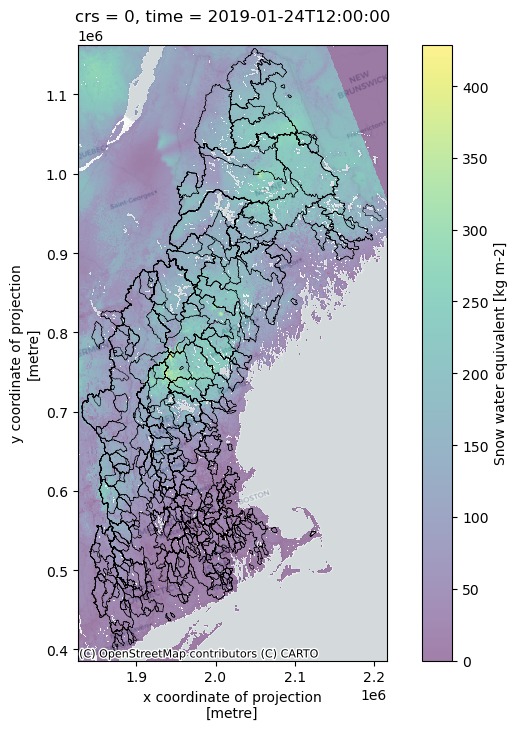

In [7]:
# Sanity check plot: one SWE time slice with the HUC2 basins overlaid
ds_slice = ds.sel(time=slice('2019-01-24 12:00:00', '2019-01-24 12:00:00')).SNEQV.persist()
fig, axs = plt.subplots(figsize=(9, 8))
ds_slice.plot(ax=axs, alpha=0.5)
sub.plot(ax=axs, facecolor='none', edgecolor='k', linewidth=0.4)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

#### 4. Get the daily ROS masks (Musselman method)

In [8]:
%%time
masks = ros.ros_musselman(ds)
masks

CPU times: user 496 ms, sys: 129 ms, total: 625 ms
Wall time: 807 ms


<xarray.Dataset> Size: 14GB
Dimensions:      (x: 390, y: 777, time: 15706)
Coordinates:
  * x            (x) float64 3kB 1.827e+06 1.828e+06 ... 2.215e+06 2.216e+06
  * y            (y) float64 6kB 3.865e+05 3.875e+05 ... 1.161e+06 1.162e+06
  * time         (time) datetime64[ns] 126kB 1979-10-01 ... 2022-09-30
    crs          int64 8B 0
    spatial_ref  int64 8B 0
Data variables:
    mask_ros     (time, y, x) int8 5GB dask.array<chunksize=(10, 144, 70), meta=np.ndarray>
    mask_rain    (time, y, x) int8 5GB dask.array<chunksize=(10, 144, 70), meta=np.ndarray>
    mask_sneqv   (time, y, x) int8 5GB dask.array<chunksize=(10, 144, 70), meta=np.ndarray>

#### 5. Save daily ROS grid (mask_ros) to Zarr

The ROS zone is built from the reloaded local masks. `mask_ros` is the daily 1/0 ROS-occurrence grid;
pass `masks_to_save=('mask_ros','mask_rain','mask_sneqv')` to save all three computed masks. Only  `mask_ros` is passed here for testing purposes.

In [9]:
%%time
masks_path = f'{saveDir}/ros_masks/ros_masks_huc{huc2}.zarr'
rosutl.save_masks_zarr(masks, masks_path, masks_to_save=('mask_ros',),
                       time_chunk=365, spatial_chunk=350)
# open_zarr restores the persisted NWM LCC CRS; define_ros_zone re-asserts it anyway.
masks_local = xarray.open_zarr(masks_path, consolidated=True)
masks_local

/users/m/m/mmorale3/.conda/envs/rosEnv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: user 1min 4s, sys: 8.25 s, total: 1min 12s
Wall time: 5min 5s


<xarray.Dataset> Size: 5GB
Dimensions:      (time: 15706, y: 777, x: 390)
Coordinates:
  * time         (time) datetime64[ns] 126kB 1979-10-01 ... 2022-09-30
  * y            (y) float64 6kB 3.865e+05 3.875e+05 ... 1.161e+06 1.162e+06
  * x            (x) float64 3kB 1.827e+06 1.828e+06 ... 2.215e+06 2.216e+06
    crs          int64 8B ...
    spatial_ref  int64 8B ...
Data variables:
    mask_ros     (time, y, x) int8 5GB dask.array<chunksize=(365, 350, 350), meta=np.ndarray>

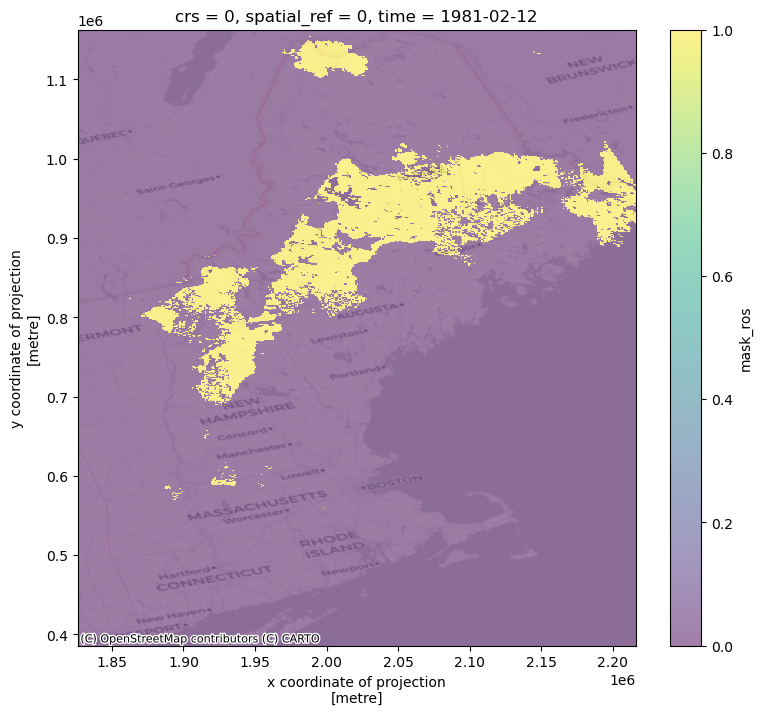

In [10]:
# Sanity plot: one daily ROS mask from the reloaded local store
test_ros = masks_local['mask_ros'].isel(time=500)
fig, axs = plt.subplots(figsize=(9, 8))
test_ros.plot(ax=axs, alpha=0.5)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

#### 6. Define the ROS zone and save as raster

In [11]:
%%time
ros_zone = ros.define_ros_zone(daily_ros_mask=masks_local['mask_ros'], threshold=threshold)

CPU times: user 891 ms, sys: 104 ms, total: 995 ms
Wall time: 2.72 s


In [12]:
# One zone raster per HUC2
zone_dir = f'{saveDir}/ros_zone'
os.makedirs(zone_dir, exist_ok=True)
ros_zone.rio.to_raster(f'{zone_dir}/ros_zone_raster_huc{huc2}.tif')
print('ROS zone raster saved.')

ROS zone raster saved.


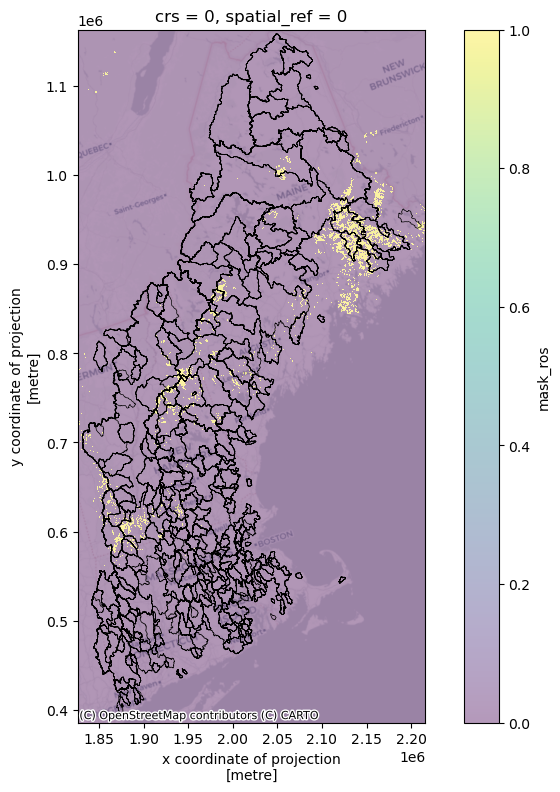

In [13]:
# Sanity check plot: Let's take a look at the basins and the ROS zone
fig, axs = plt.subplots(figsize=(10, 9))
ros_zone.plot(ax=axs, alpha=0.4)
sub.plot(ax=axs, facecolor='none', edgecolor='k', linewidth=0.5)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

#### 7. Per-basin ROS zone coverage percentage (ref and non-ref)

In [14]:
%%time
results = []
for cls in bsn_class:
    shp = sub[sub['CLASS'] == cls]
    if len(shp) == 0:
        continue
    # Per-basin ROS zone coverage lives under output/ros_zone/<cls>/ (the raster stays at ros_zone root).
    zone_cls_dir = f'{saveDir}/ros_zone/{cls}'
    os.makedirs(zone_cls_dir, exist_ok=True)
    df = ros.get_ros_basins(ros_zone=ros_zone, shp=shp)
    df.to_parquet(f'{zone_cls_dir}/ros_zone_gagesii_{cls}_huc{huc2}.parquet', index=False)
    df.to_csv(f"{zone_cls_dir}/ros_zone_gagesii_{cls}_huc{huc2}.csv", index=False)
    results.append(df)
    print(f'{cls}: {len(shp)} basins -> {len(df)} in ROS zone')
ros_zone_all = pd.concat(results, ignore_index=True)
len(ros_zone_all['GAGE_ID'].unique())

ref: 97 basins -> 39 in ROS zone
nonref: 274 basins -> 99 in ROS zone
CPU times: user 4.82 s, sys: 92.9 ms, total: 4.91 s
Wall time: 4.97 s


138

#### 8. Define daily ROS events per basin (ref and non-ref)

In [15]:
%%time
results = []
for cls in bsn_class:
    shp = sub[sub['CLASS'] == cls]
    if len(shp) == 0:
        continue
    # Daily ROS event records live under output/ros_events/<cls>/.
    events_dir = f'{saveDir}/ros_events/{cls}'
    os.makedirs(events_dir, exist_ok=True)
    print(f'Processing {cls}...')
    df = ros.batch_processor(ds=masks, func=ros.get_ros_events,
                             batch_size_years=batch_size_years, shp=shp)
    df.to_parquet(f'{events_dir}/ros_events_gagesii_{cls}_huc{huc2}.parquet', index=False)
    df.to_csv(f"{events_dir}/ros_events_gagesii_{cls}_huc{huc2}.csv", index=False)
    results.append(df)
    print(f'{cls}: {len(shp)} basins -> {len(df):,} event records')
ros_events_all = pd.concat(results, ignore_index=True)
ros_events_all.head()

Processing ref...
--- Processing 1979 to 1980 --- | compute 9.6s | extract 8.6s | total 18.3s
--- Processing 1981 to 1982 --- | compute 14.9s | extract 14.0s | total 28.8s
--- Processing 1983 to 1984 --- | compute 15.2s | extract 13.5s | total 28.7s
--- Processing 1985 to 1986 --- | compute 15.0s | extract 13.6s | total 28.6s
--- Processing 1987 to 1988 --- | compute 14.9s | extract 13.6s | total 28.5s
--- Processing 1989 to 1990 --- | compute 14.8s | extract 13.8s | total 28.6s
--- Processing 1991 to 1992 --- | compute 14.9s | extract 13.5s | total 28.4s
--- Processing 1993 to 1994 --- | compute 15.0s | extract 13.9s | total 28.9s
--- Processing 1995 to 1996 --- | compute 15.0s | extract 13.5s | total 28.4s
--- Processing 1997 to 1998 --- | compute 15.3s | extract 13.5s | total 28.9s
--- Processing 1999 to 2000 --- | compute 14.7s | extract 13.6s | total 28.3s
--- Processing 2001 to 2002 --- | compute 14.6s | extract 13.6s | total 28.2s
--- Processing 2003 to 2004 --- | compute 16.0s 

,GAGE_ID,Date,Perc_ROS,Perc_Rain,Perc_SWE
0,01144000,1979-10-12,0.6,2.1,13.8
1,01137500,1979-11-02,0.5,49.4,0.5
2,01138000,1979-11-02,0.1,70.8,0.1
3,01033500,1979-11-03,0.9,99.6,0.9
4,01064300,1979-11-03,4.7,100.0,4.7


Outputs for this HUC2 are written under `output_sandbox/` as example of the functions usage and for testing purposes. The final products at conus scale stored in `../output/`.

The production chain for all CONUS regions is three steps:

1. `HPC_scripts/get_percRos_evs_perHuc2.py` excecutes codes on an HPC (VACC) at a conus scale — masks +
   events per HUC2. This is the only step that reads NWM from the AWS S3.
2. `create_conus_ros_data.py` — merges the per-HUC2 event tables into `output/conus/`.
3. `run_zone_thresholds.py` — creates the ROS zone at every frequency bin plus the ROS-day counts over conus, all built from the persisted masks and joined to create conus scale data.
